## **Hello and Welcome to this notebook for calculating NDVI for a sample .tif format file**
In the first two cells necessary libraries has been prepared.

In [1]:
!pip install earthpy

     |████████████████████████████████| 1.4 MB 4.4 MB/s 
  Installing build dependencies ... - \ | / done
  Getting requirements to build wheel ... - done
    Preparing wheel metadata ... - done
  Created wheel for earthpy: filename=earthpy-0.9.2-py3-none-any.whl size=1365087 sha256=cad6ed01b92b3aa52cede97ee2222798bb9357edbdca4a0d01596aef69c9ce4d
  Stored in directory: /root/.cache/pip/wheels/c3/02/7a/1fe4f9b993cf451f1c9f22f0ea9659481408b9478e4a3bd237
Successfully built earthpy


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import geopandas as gpd
import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep

For demonstration purpose we are going to use ***cold-springs-fire*** dataset. A ***.tif*** formatted file having 4 bands (Red, Green, Blue, Near-Infrared respectively), each containing (2312,4377) pixels has been used for calculation purpose

In [3]:
# Downloading data using below code
data = et.data.get_data('cold-springs-fire')

Extracted output to /root/earth-analytics/data/cold-springs-fire/.


In [4]:
# Let's set the working directory
os.chdir(os.path.join(et.io.HOME, 'earth-analytics'))

In [5]:
# Defining the path of the '.tif' file to be used
naip_data_path = os.path.join("data", "cold-springs-fire", 
                              "naip", "m_3910505_nw_13_1_20150919", 
                              "crop", "m_3910505_nw_13_1_20150919_crop.tif")

In [6]:
naip_data_path

'data/cold-springs-fire/naip/m_3910505_nw_13_1_20150919/crop/m_3910505_nw_13_1_20150919_crop.tif'

In [7]:
# opening the data using rasterio module as shown below
with rio.open(naip_data_path) as src:
    naip_data = src.read()

In [8]:
naip_data.shape

(4, 2312, 4377)

For the calculation of NDVI we need only Near-Infrared and Red band values which is the 4th and 1st layer respectively.

earthpy.spatial submodule has a method that can do this task for us. That is ***earthpy.spatial.normalized_diff***

In [9]:
# Calculating NDVI by considering 1st and 4th layer 
naip_ndvi = es.normalized_diff(naip_data[3], naip_data[0])

In [10]:
naip_ndvi

array([[ 0.12403101,  0.1       ,  0.00724638, ...,  0.15625   ,
        -0.04081633, -0.0647482 ],
       [ 0.12403101,  0.11026616,  0.02962963, ...,  0.2173913 ,
         0.04424779,  0.02702703],
       [ 0.12252964,  0.10344828,  0.09090909, ...,  0.20812183,
         0.16939891,  0.01886792],
       ...,
       [-0.06703911, -0.06371191, -0.05753425, ...,  0.13432836,
         0.20689655,  0.22051282],
       [-0.06077348, -0.05785124, -0.06043956, ...,  0.0619469 ,
         0.13286713,  0.19318182],
       [-0.05464481, -0.05464481, -0.05177112, ..., -0.07368421,
        -0.03508772,  0.0075188 ]])

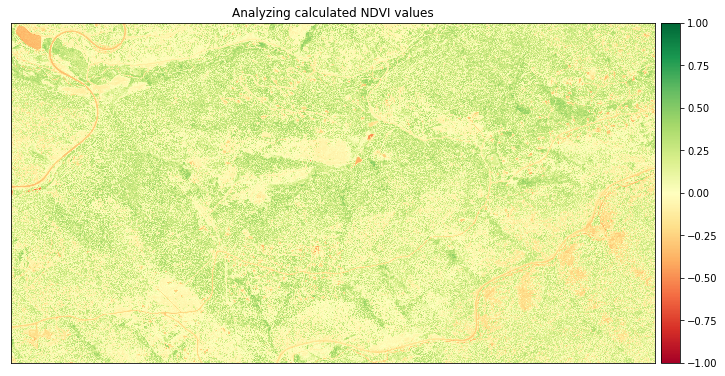

In [11]:
# Let's now visualize the NDVI values using earthpy.plot submodule
ep.plot_bands(naip_ndvi, cmap='RdYlGn', scale=False, vmin=-1, vmax=1,
              title="Analyzing calculated NDVI values")
plt.show()

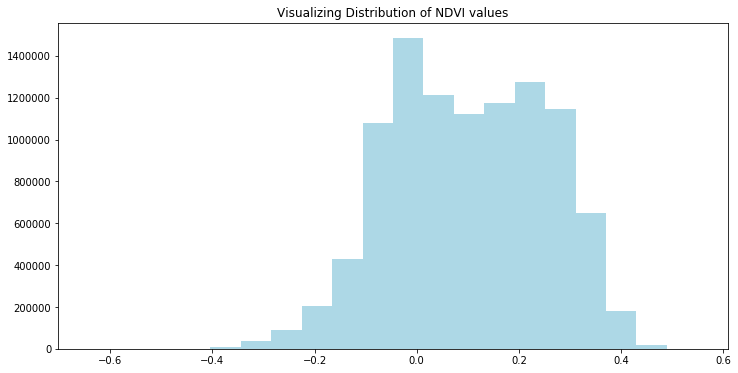

In [12]:
# Plotting a histogram will be much more informative and accurate.
ep.hist(naip_ndvi, colors='lightblue' ,figsize=(12, 6),
        title=["Visualizing Distribution of NDVI values"])

plt.show()

### Results:
* It can be observed from above histogram that a majority of the values of NDVI is lying between -0.1 to 0.3.
* NDVI values corresponding to dense vegetation (approx 0.6 to 0.9) has not been observed at all.
* It can be estimated that majorly the analyzed land field probably consist of just sand, rock, roads, etc. along with some shrubs, grasslands, senescing crops, etc.

### References
I would like to mention some references that helped me in carrying out this work:
* [https://www.earthdatascience.org/](http://)
* [https://earthpy.readthedocs.io/en/v0.6.4/index.html](http://)
* [https://rasterio.readthedocs.io/en/latest/index.html](http://)

Thanks for your time.